<a href="https://colab.research.google.com/github/EdgarOmarCruzGutierrez/ML_from_Scratch/blob/main/regresion_lineal/descenso_gradiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descenso del gradiente a MSE

Este notebook aplica descenso del gradiente a la función MSE para una regresión lineal.


## 1.- Lo primero que hacemos es importar la biblioteca que requerimos

## 2.- Generar el conjunto de datos de entrenamiento y la variable a predecir Y.


In [214]:
import numpy as np
import matplotlib.pyplot as plt
X_raw = np.array([1.55,1.60,1.63,1.68,1.70,1.73,1.75,1.78,1.80,1.83])
Y = np.array([55.84,58.57,59.93,63.11,64.47,66.28,68.10,69.92,72.19,74.46])



## 4.- Generamos las funciones auxiliares para poder evaluar el gradiente

#### 4.1 Definimos nuestra función de escalado para que el algoritmo converja más rápido

#### 4.2 Definimos la función getY_hat para obtener la predicción de Y al paso n

#### 4.3 Definimos get_partial que es una función que calcula las derivadas parciales respecto a w_0 y respecto a w_1

#### 4.4 Definimos MSE que es una función cuya utilidad es calcular el error promedio  una vez que terminamos de iterar sobre las epochs decididas

#### 4.5 Definimos la función descenso que calcula cómo van actualizándose los valores de w_0 y w_1 conforme se itera con el learning rate definido y las epochs definidas.

#### 4.6 Definimos get_Weights_Prediction que es una función que obtiene los pesos w_0 y w_1 así como el valor predicho una vez que el algoritmo converge.

In [215]:
def scaler(X, option, value=0,):
  mu_x= np.mean(X)
  sigma_x= np.std(X)
  if option ==1:
    return (value-mu_x)/sigma_x
  else:
    return (X-mu_x)/sigma_x

In [216]:
def getY_hat(w_0, w_1, X):
  y_hat=[]
  for x in X:
    pred= w_0 + w_1*(x)
    y_hat.append(pred)

  return np.array(y_hat)

In [217]:
def get_partial(Y,Y_hat, X):
  numerador1, numerador2= 0,0
  denominador= len(Y)
  for y,y_hat,x in zip(Y,Y_hat,X):
    numerador1+= (-2)*(y-y_hat)
    numerador2+= (-2)*(y-y_hat)*x
  pw_0= numerador1/denominador
  pw_1= numerador2/ denominador

  return pw_0, pw_1



In [218]:
def MSE(Y, Y_hat):
  denominador= len(Y)
  numerador = 0
  for y, y_hat in zip(Y, Y_hat):
    numerador += (y-y_hat)**2
  mse= numerador/denominador


  return mse

In [219]:
def descenso(lr, epochs, X, Y):
  w_0=0
  w_1= 0
  valores_mse= []

  for _ in range(epochs):
        Y_hat = getY_hat(w_0, w_1, X)

        pw_0, pw_1 = get_partial(Y, Y_hat, X)
        w_0 = w_0 - (lr * pw_0)
        w_1 = w_1 - (lr * pw_1)
        mse= MSE(Y,Y_hat)
        valores_mse.append(mse)


  valores_mse.append(MSE(Y, getY_hat(w_0, w_1, X)))
  print(valores_mse[-1])

  return w_1, w_0, valores_mse

In [220]:
def get_Weights_Prediction(X,Y, lr, epochs, estatura):
  w_1, w_0, valores_mse = descenso(lr, epochs, X,Y)
  peso = w_0 + w_1*estatura

  return w_0, w_1, peso, valores_mse


# 5.- Agregamos una función para graficar cómo se comporta con diferentes hiperparametros

In [221]:
COLORES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MARCADORES = ["o", "s", "^", "D", "v", "P", "X", "*"]

def graficar_mse(corridas):

  plt.figure(figsize=(9, 5.5), facecolor="white")
  ax = plt.gca()

  for i, (etiqueta, valores_mse) in enumerate(corridas):
    ultima = len(valores_mse) - 1


    plt.plot(range(ultima + 1), valores_mse, label=etiqueta, linewidth=2,
             color=COLORES[i % len(COLORES)],
             marker=MARCADORES[i % len(MARCADORES)], markevery=[ultima],
             markersize=10, markeredgecolor="white", markeredgewidth=2)


    plt.annotate(f"{valores_mse[-1]:.2f}", (ultima, valores_mse[-1]),
                 xytext=(10, 0), textcoords="offset points", va="center")


  plt.xscale("symlog", linthresh=1)
  plt.yscale("log")
  ax.xaxis.set_major_formatter("{x:g}")
  ax.yaxis.set_major_formatter("{x:g}")
  mas_larga = max(len(valores_mse) for _, valores_mse in corridas) - 1
  plt.xlim(0, 4 * mas_larga)

  plt.xlabel("Época (escala logarítmica; 0 = antes de entrenar)")
  plt.ylabel("MSE (escala logarítmica)")
  plt.title("Error por época según el learning rate y el escalado")
  plt.grid(True, color="#e1e0d9", linewidth=1)
  ax.set_axisbelow(True)
  ax.spines[["top", "right"]].set_visible(False)
  plt.legend(frameon=False)
  plt.show()

## 6.- Probamos

0.31357578451178286
w_0: 65.2870, w_1: 5.7227, Peso predicho: 64.2908
4295.455089999875
w_0: 0.0000, w_1: 0.0000, Peso predicho: -0.0000
5.300278656774898
w_0: -3.7083, w_1: 40.5157, Peso predicho: 64.7632
0.3135757845117793
w_0: 65.2870, w_1: 5.7227, Peso predicho: 64.2908


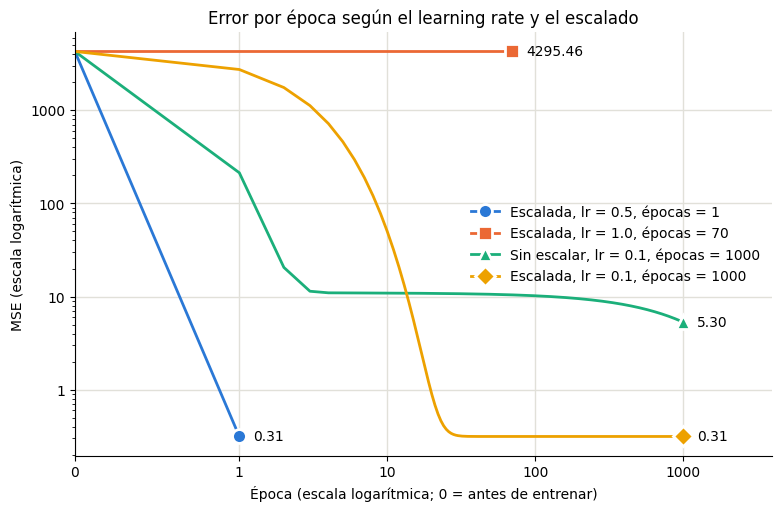

In [222]:
height = scaler(X_raw, 1, 1.69)
X = scaler(X_raw, 0)

parametros = [
    (X, Y, 0.5, 1, height, "Escalada"),
    (X, Y, 1.0, 70, height, "Escalada"),
    (X_raw, Y, 0.1, 1000, 1.69, "Sin escalar"),
    (X, Y, 0.1, 1000, height, "Escalada"),
]

corridas = []
for X_curr, Y_curr, lr, epochs, h, nombre in parametros:
  w_0, w_1, peso, valores_mse = get_Weights_Prediction(X_curr, Y_curr, lr, epochs, h)
  print(f"w_0: {w_0:.4f}, w_1: {w_1:.4f}, Peso predicho: {peso:.4f}")
  corridas.append((f"{nombre}, lr = {lr}, épocas = {epochs}", valores_mse))

graficar_mse(corridas)

## 7.-Comparamos contra scikit-learn

In [223]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


w_0, w_1, peso, _ = get_Weights_Prediction(X, Y, 0.1, 1000, height)
mse = MSE(Y, getY_hat(w_0, w_1, X))

# Versión estándar: scikit-learn no itera, resuelve mínimos cuadrados directamente
X_columna = X.reshape(-1, 1)   # scikit-learn espera una columna por variable
modelo = LinearRegression().fit(X_columna, Y)
w_0_sk = modelo.intercept_
w_1_sk = modelo.coef_[0]
peso_sk = modelo.predict([[height]])[0]
mse_sk = mean_squared_error(Y, modelo.predict(X_columna))

print(f"{'':<15}{'Mi versión':>14}{'scikit-learn':>14}{'Diferencia':>14}")
comparacion = [("w_0", w_0, w_0_sk), ("w_1", w_1, w_1_sk),
               ("Peso predicho", peso, peso_sk), ("MSE", mse, mse_sk)]
for nombre, mio, sk in comparacion:
  print(f"{nombre:<15}{mio:>14.6f}{sk:>14.6f}{abs(mio - sk):>14.1e}")

0.3135757845117793
                   Mi versión  scikit-learn    Diferencia
w_0                 65.287000     65.287000       2.8e-14
w_1                  5.722687      5.722687       8.9e-16
Peso predicho       64.290808     64.290808       2.8e-14
MSE                  0.313576      0.313576       3.9e-16
